In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading All Datasets
customers = pd.read_csv("../Datasets/customers.csv")
orders = pd.read_csv("../Datasets/orders.csv")
order_items = pd.read_csv("../Datasets/order_item.csv")
payments = pd.read_csv("../Datasets/payments.csv")
products = pd.read_csv("../Datasets/products.csv")
reviews = pd.read_csv("../Datasets/reviews.csv")
sellers = pd.read_csv("../Datasets/sellers.csv")
categories = pd.read_csv("../Datasets/category_translation.csv")


orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
 # Data Integration (Critical Component)
# ==========================================================
# DATA INTEGRATION: BUILDING MASTER DATASET
# ==========================================================
# Objective:
# Combine multiple relational tables into a single unified dataset
# to create a Customer 360 view for analysis.

# Approach:
# - Use LEFT JOIN to preserve all orders (main table)
# - Merge supporting tables step-by-step using appropriate keys
# - Maintain data integrity without losing records

# Key Learning:
# - One-to-many relationships (order_items, payments) increase rows
# - Data duplication is expected and handled later during aggregation
# ==========================================================

# Step 1: orders + customers

master_df = pd.merge(
    orders, customers, 
    on='customer_id', how='left'
)
print("After customers merge:", master_df.shape)


# Step 2: order_items
master_df = pd.merge(
    master_df, order_items, 
    on='order_id', how='left'
)
print("After order_items merge:", master_df.shape)


# Step 3: products
master_df = pd.merge(
    master_df, products, 
    on='product_id', how='left'
)
print("After products merge:", master_df.shape)



# Step 4: payments
master_df = pd.merge(
    master_df, payments, 
    on='order_id', how='left'
)
print("After payments merge:", master_df.shape)

# Step 5: reviews
master_df = pd.merge(
    master_df, reviews, 
    on='order_id', how='left'
)
print("After reviews merge:", master_df.shape)


# Step 6: sellers
master_df = pd.merge(
    master_df, sellers, 
    on='seller_id', how='left'
)
print("After sellers merge:", master_df.shape)



print('Analyze null values:\n',master_df.isnull().sum())

master_df.head()


#NOTE:
# Due to multiple one-to-many joins, the dataset now contains
# repeated order_id values. Each row represents a combination of:
# order + item + payment (+ review + seller)
# This is expected and will be handled during aggregation.

After customers merge: (99441, 12)
After order_items merge: (113425, 18)
After products merge: (113425, 26)
After payments merge: (118434, 30)
After reviews merge: (119143, 36)
After sellers merge: (119143, 39)
Analyze null values:
 order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,14840.0,guariba,SP


In [4]:
master_df['payment_value']=master_df['payment_value'].fillna(0)
date_cols=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
]
for col in date_cols:
    master_df[col]=pd.to_datetime(master_df[col])

master_df[date_cols].dtypes
# We have converted to datetime to perform calculation and time based analysis
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [5]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================
# Objective:
# Transform raw data into meaningful features that help in
# analyzing customer behavior, revenue patterns, and operations.

# Key Concepts:
# - Derive new features from existing columns
# - Handle duplication effects using aggregation
# - Create business-relevant metrics

# Outcome:
# Enhanced dataset with actionable features for EDA and insights
# ==========================================================



# 1. Delivery time
master_df['delivery_time'] = (
    master_df['order_delivered_customer_date'] -
    master_df['order_purchase_timestamp']
).dt.days

# 2. Order month
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# 3. Number of items per order
items_per_order = master_df.groupby('order_id')['order_item_id'].count()
master_df = master_df.merge(items_per_order.rename('num_items'), on='order_id')

# 4.Total order value
order_value = payments.groupby('order_id')['payment_value'].sum()
master_df = master_df.merge(order_value.rename('total_order_value'), on='order_id')

# 5. Customer purchase frequency
customer_orders = master_df.groupby('customer_unique_id')['order_id'].nunique()
master_df = master_df.merge(customer_orders.rename('customer_order_count'), on='customer_unique_id')

# 6. Average order value per customer
avg_order_value = master_df.groupby('customer_id')['total_order_value'].mean()
master_df = master_df.merge(avg_order_value.rename('avg_order_value'), on='customer_id')



master_df[['delivery_time', 'order_month', 'num_items',
           'total_order_value', 'customer_order_count',
           'avg_order_value']].head()



,delivery_time,order_month,num_items,total_order_value,customer_order_count,avg_order_value
0,8.0,2017-10,3,38.71,2,38.71
1,8.0,2017-10,3,38.71,2,38.71
2,8.0,2017-10,3,38.71,2,38.71
3,13.0,2018-07,1,141.46,1,141.46
4,9.0,2018-08,1,179.12,1,179.12


In [6]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,delivery_time,order_month,num_items,total_order_value,customer_order_count,avg_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-12 03:43:48,9350.0,maua,SP,8.0,2017-10,3,38.71,2,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-12 03:43:48,9350.0,maua,SP,8.0,2017-10,3,38.71,2,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-12 03:43:48,9350.0,maua,SP,8.0,2017-10,3,38.71,2,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08 18:37:50,31570.0,belo horizonte,SP,13.0,2018-07,1,141.46,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-22 19:07:58,14840.0,guariba,SP,9.0,2018-08,1,179.12,1,179.12


Repeated Customers: 2997
New Customers: 93098


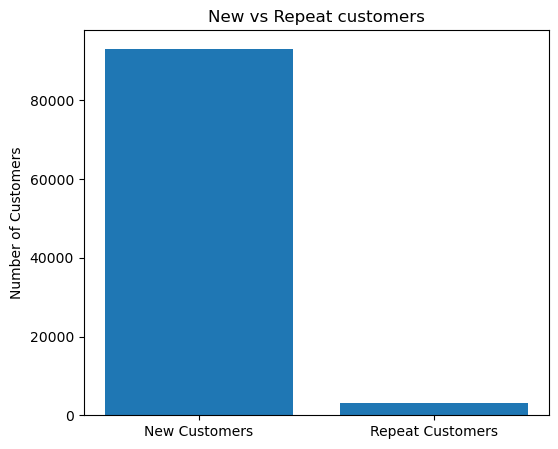

customer_state
SP    50262
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
Name: count, dtype: int64


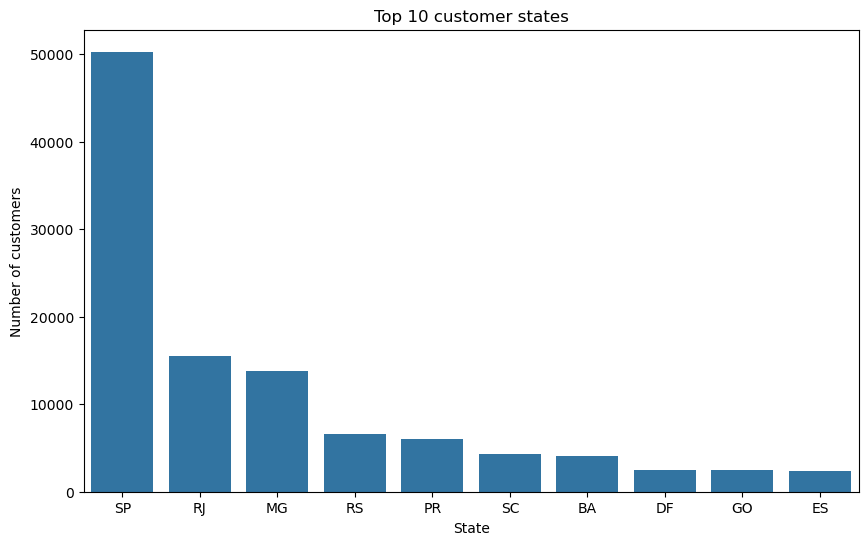

In [7]:
# Customer Analysis
repeated_customers=customer_orders[customer_orders>1].count()
new_customers=customer_orders[customer_orders==1].count()
print('Repeated Customers:',repeated_customers)
print('New Customers:',new_customers)

plt.figure(figsize=(6,5))
plt.bar(['New Customers','Repeat Customers'],[new_customers,repeated_customers])
plt.title('New vs Repeat customers')
plt.ylabel('Number of Customers')
plt.show()


top_states=master_df['customer_state'].value_counts().head(10)
print(top_states)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.index,
            y=top_states.values)
plt.title('Top 10 customer states')
plt.xlabel('State')
plt.ylabel('Number of customers')
plt.show()

order_month
2016-09        388.47
2016-10      78300.24
2016-12         19.62
2017-01     200889.38
2017-02     370556.66
2017-03     585424.97
2017-04     549454.40
2017-05     784151.12
2017-06     639485.89
2017-07     803760.70
2017-08     933750.22
2017-09    1089739.45
2017-10    1086765.39
2017-11    1662866.15
2017-12    1099013.92
2018-01    1482208.57
2018-02    1379331.44
2018-03    1539787.57
2018-04    1542962.27
2018-05    1567050.87
2018-06    1366302.63
2018-07    1413475.59
2018-08    1289984.14
2018-09       4439.54
2018-10        589.67
Freq: M, Name: total_order_value, dtype: float64


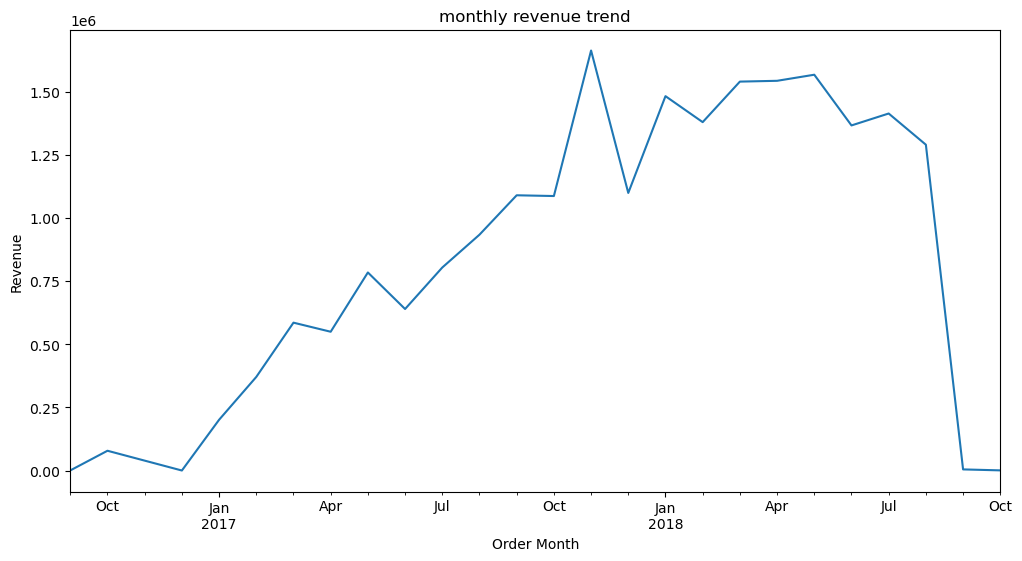

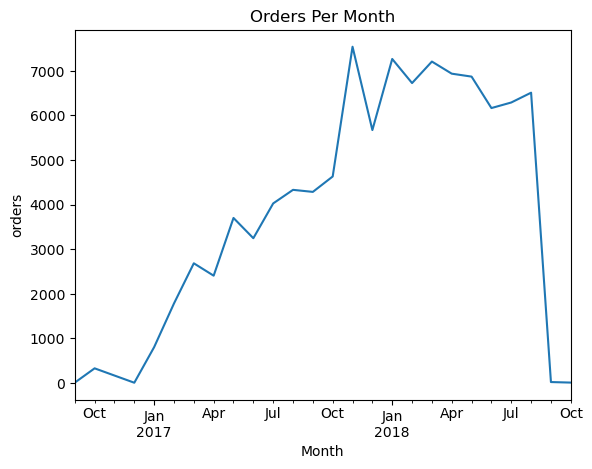

In [8]:
# Revemue Analysis
monthly_revenue=master_df.groupby('order_month')['total_order_value'].sum()
print(monthly_revenue)

plt.figure(figsize=(12,6))
monthly_revenue.plot()
plt.title('monthly revenue trend')
plt.xlabel('Order Month')
plt.ylabel('Revenue')
plt.show()


monthly_orders=master_df.groupby('order_month')['order_id'].nunique()
monthly_orders.plot()
plt.title('Orders Per Month')
plt.xlabel('Month')
plt.ylabel('orders')
plt.show()


product_category_name
cama_mesa_banho           11988
beleza_saude              10029
esporte_lazer              9004
moveis_decoracao           8832
informatica_acessorios     8150
utilidades_domesticas      7380
relogios_presentes         6213
telefonia                  4726
ferramentas_jardim         4590
automotivo                 4400
Name: count, dtype: int64


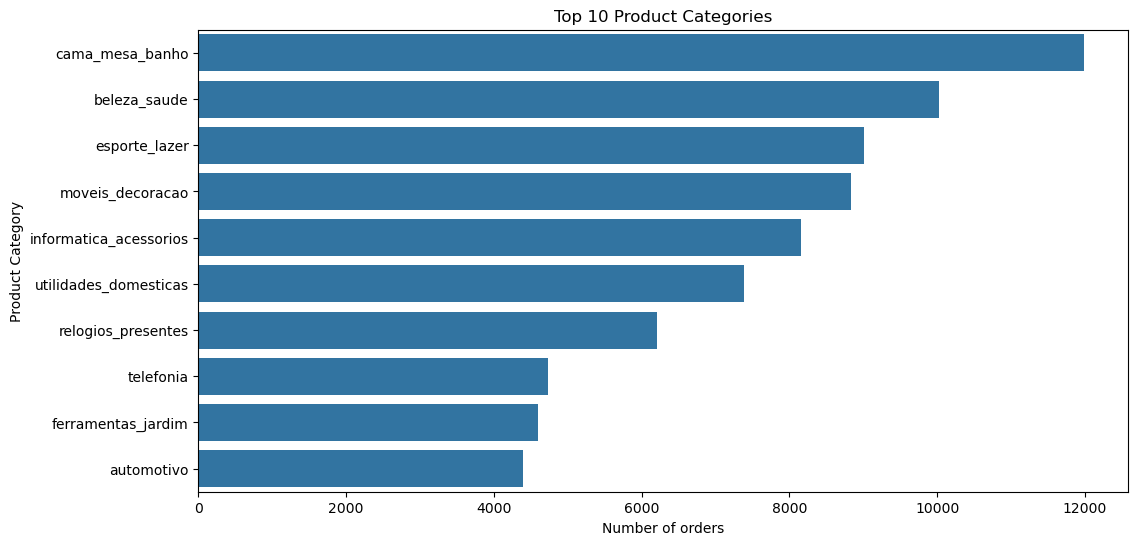

product_category_name
cama_mesa_banho           1841234.83
beleza_saude              1723154.53
informatica_acessorios    1642792.28
moveis_decoracao          1504819.72
relogios_presentes        1483921.98
Name: total_order_value, dtype: float64


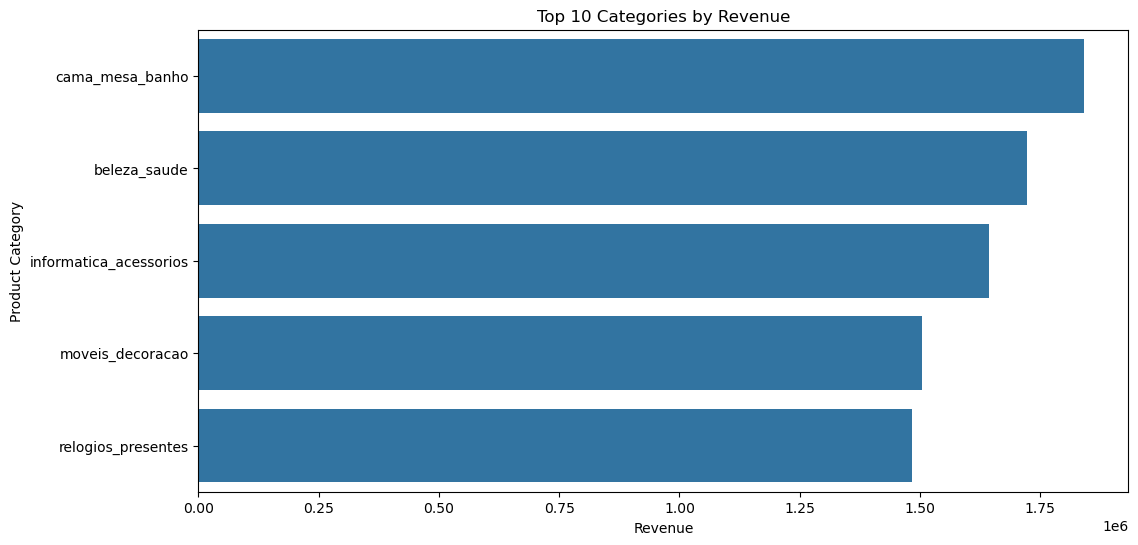

In [9]:
# product analysis
top_categories=master_df['product_category_name'].value_counts().head(10)
print(top_categories)

plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.values,y=top_categories.index)
plt.title('Top 10 Product Categories')
plt.xlabel('Number of orders')
plt.ylabel('Product Category')

plt.show()

category_revenue=master_df.groupby('product_category_name')['total_order_value'].sum().sort_values(ascending=False).head()
print(category_revenue)

plt.figure(figsize=(12,6))
sns.barplot(x=category_revenue.values,y=category_revenue.index)

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.show()

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64


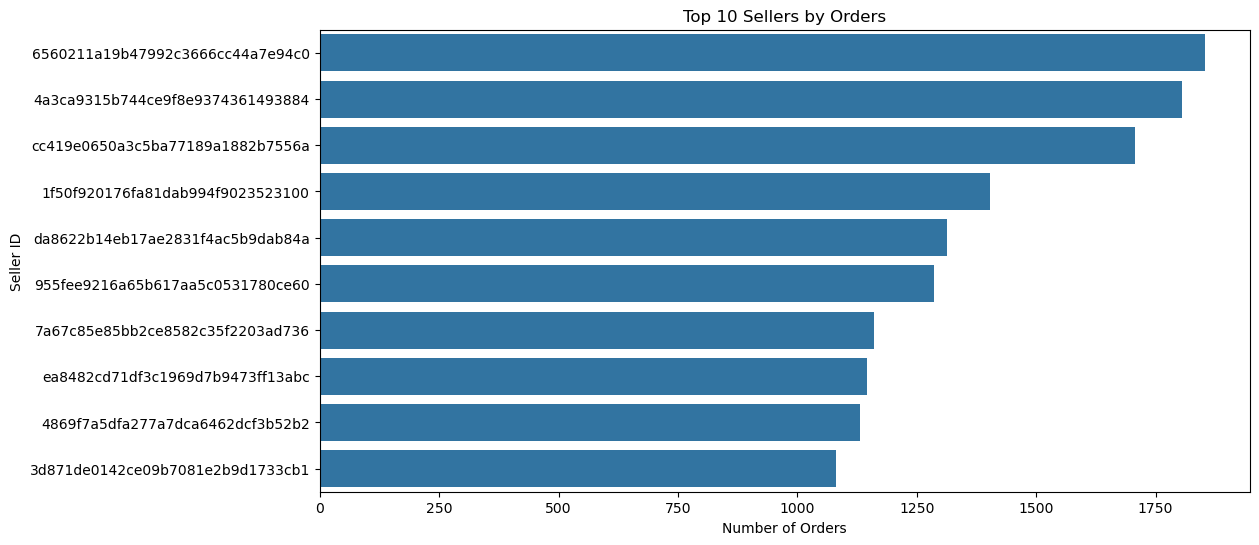

In [10]:
# ==========================================================
# SELLER ANALYSIS
# ==========================================================

# ----------------------------------------------------------
# Top Sellers by Orders
# ----------------------------------------------------------

top_sellers = master_df.groupby(
    'seller_id'
)['order_id'].nunique().sort_values(
    ascending=False
).head(10)

print(top_sellers)


# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sellers.values,
    y=top_sellers.index
)

plt.title('Top 10 Sellers by Orders')

plt.xlabel('Number of Orders')

plt.ylabel('Seller ID')

plt.show()


# Observation:
# A small group of sellers contributes a large number
# of total orders on the platform.

review_score
1.0    15425
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64


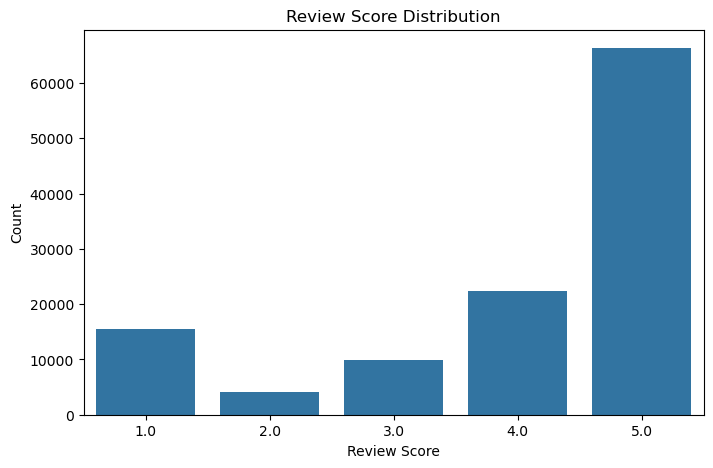

In [11]:
# ==========================================================
# REVIEW ANALYSIS
# ==========================================================

# ----------------------------------------------------------
# Review Score Distribution
# ----------------------------------------------------------

review_distribution = master_df[
    'review_score'
].value_counts().sort_index()

print(review_distribution)


# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=review_distribution.index,
    y=review_distribution.values
)

plt.title('Review Score Distribution')

plt.xlabel('Review Score')

plt.ylabel('Count')

plt.show()


# Observation:
# Most customers provide high review scores,
# indicating generally positive customer satisfaction.

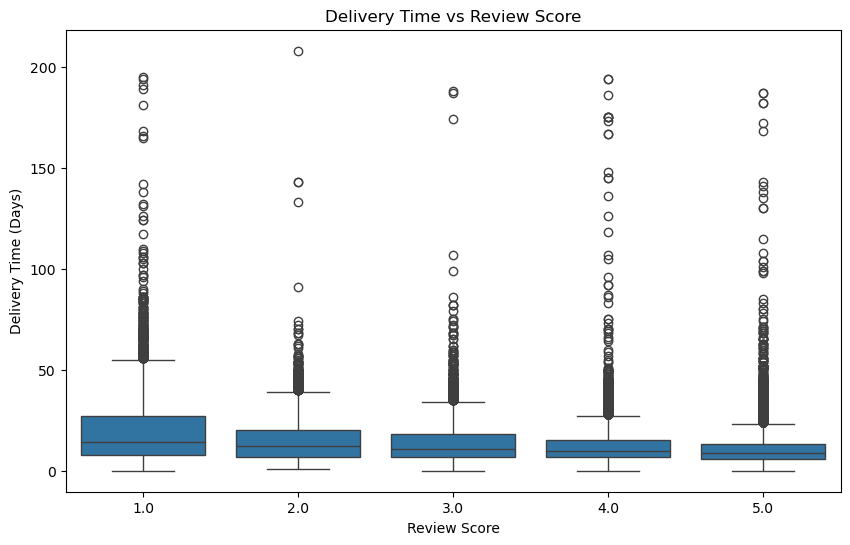

In [12]:
# ----------------------------------------------------------
# Delivery Time vs Review Score
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.boxplot(
    x='review_score',
    y='delivery_time',
    data=master_df
)

plt.title('Delivery Time vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Time (Days)')
plt.show()

# Observation:
# Orders with longer delivery times tend to receive
# lower review scores from customers.

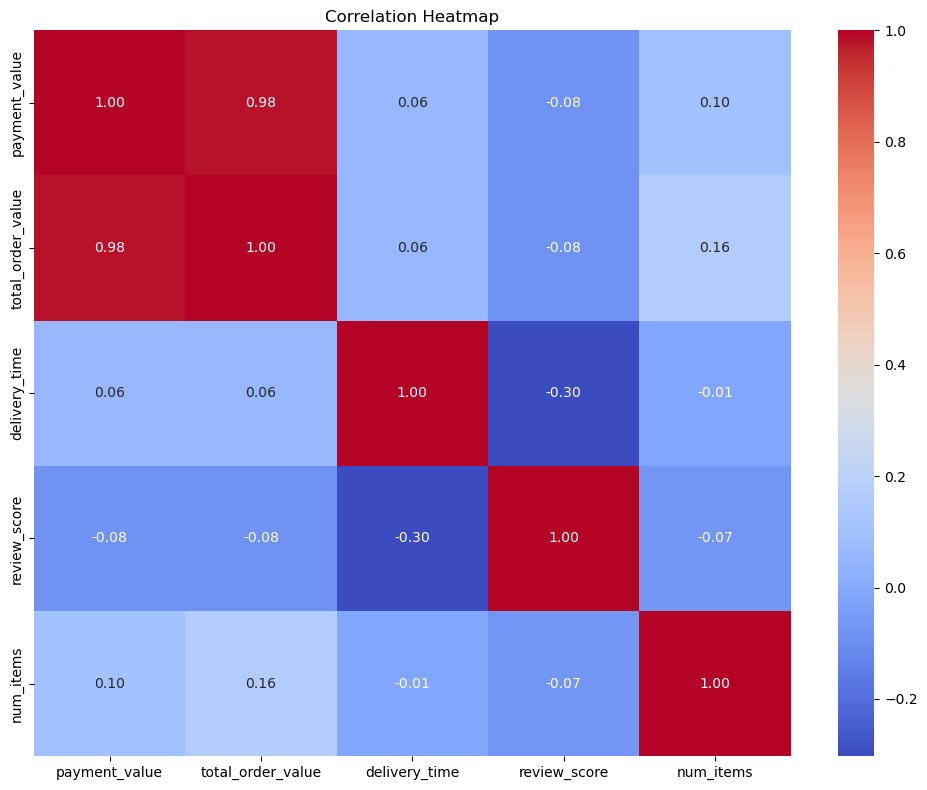

In [13]:
# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

numeric_columns = [
    'payment_value',
    'total_order_value',
    'delivery_time',
    'review_score',
    'num_items'
]

correlation = master_df[numeric_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()


# ----------------------------------------------------------
# Observation
# ----------------------------------------------------------

# The heatmap shows the relationships between numerical
# variables in the dataset. Total order value and payment
# value exhibit a strong positive correlation, while
# delivery time has a slight negative correlation with
# review scores, suggesting delayed deliveries may reduce
# customer satisfaction.

# Business Insights

1. Most customers are one-time buyers, indicating low customer retention.

2. Certain states contribute the highest number of customers and revenue.

3. Revenue fluctuates monthly, showing seasonal purchasing patterns.

4. A few product categories generate the majority of revenue.

5. Top sellers contribute a significant share of platform orders.

6. Longer delivery times tend to reduce customer satisfaction and review scores.

# Recommendations 
1. Introduce customer loyalty and retention programs.
   
2. Focus marketing campaigns on high-performing states.

3. Improve logistics and delivery efficiency.

4. Promote high-revenue product categories more aggressively.

5. Monitor seller performance to maintain service quality.